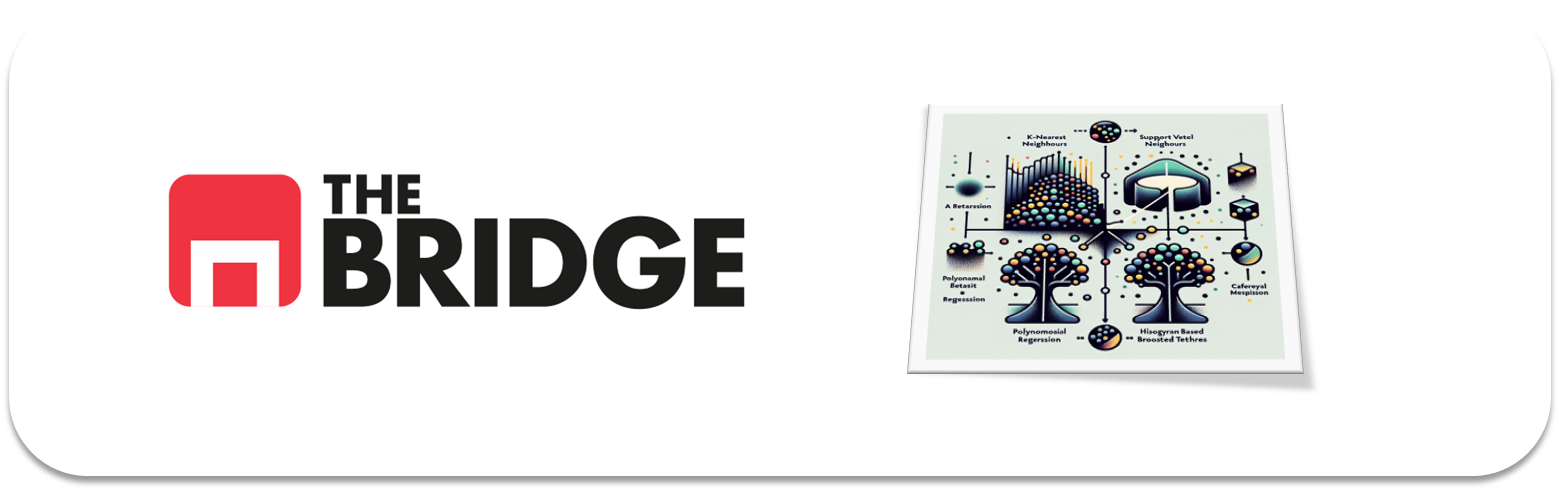

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [7]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE
from sklearn.utils import resample

pd.options.mode.copy_on_write = True

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [8]:
df= pd.read_csv ("./data/credit_npo.csv")
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [10]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

- Tipo de problema y variable target

    - Este es un porblema de clasificación binaria, ya que queremos predecir si una persona tendrá dificultades financieras o no (si/no).
    - Variable target: SeriousDlqin2yrs (1 si tuvo problemas, 0 si no)


### #1.3
Pinta la distribución de frecuencias del target y coméntala

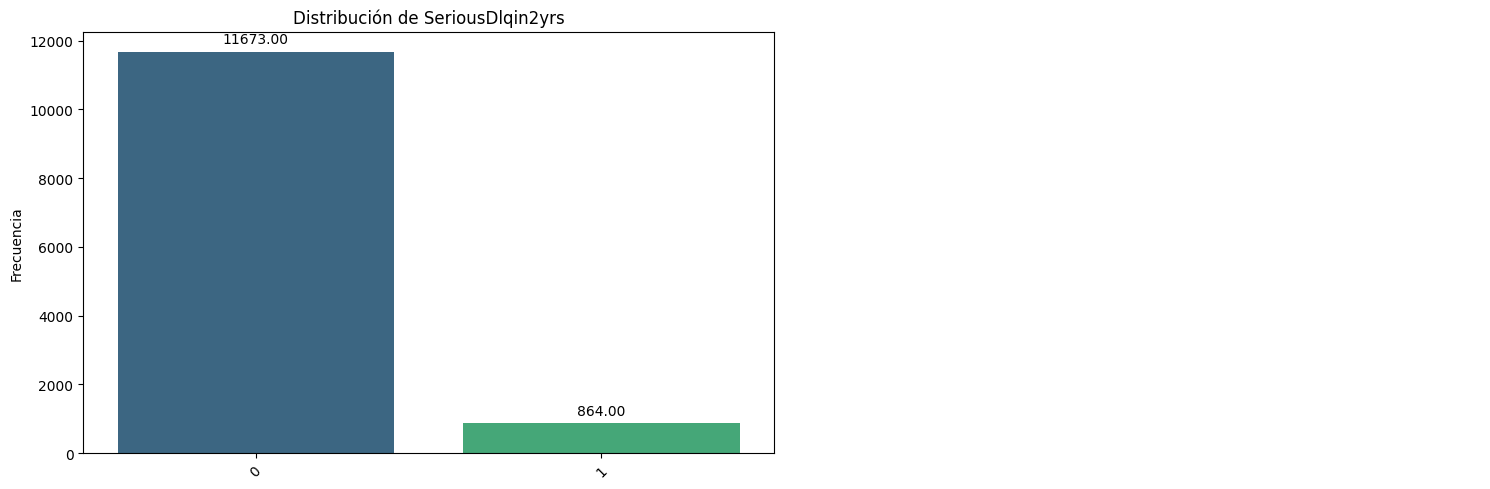

In [11]:
target = "SeriousDlqin2yrs"

bt.pinta_distribucion_categoricas(df, [target], mostrar_valores=True, relativa=False)

In [31]:
print(y_train.value_counts(normalize=True).round(3) * 100)

SeriousDlqin2yrs
0    93.1
1     6.9
Name: proportion, dtype: float64


- El tarjet está muy desbalanceado. La gráfica muestra que:
    - Clase 0 (sin problemas): 11.673 personas (93.1%)
    - Clase 1 (con problemas): 864 personas (6.9%) 

- El problema en esta gráfica es que al haber pocos casos con problemas financieros, el modelo podría aprender a decir siempre que no. 

- Para correguir este desbalance aplicaré tres técnicas:
    - Oversampling: para crear ejemplos sintéticos de la clase minoritaria
    - Undersampling: para reducir ejemplos de la clase mayoritaria
    - Equilibrado con hiperparámetros: para ajustar los modelos con class_weight

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

- # Mini EDA


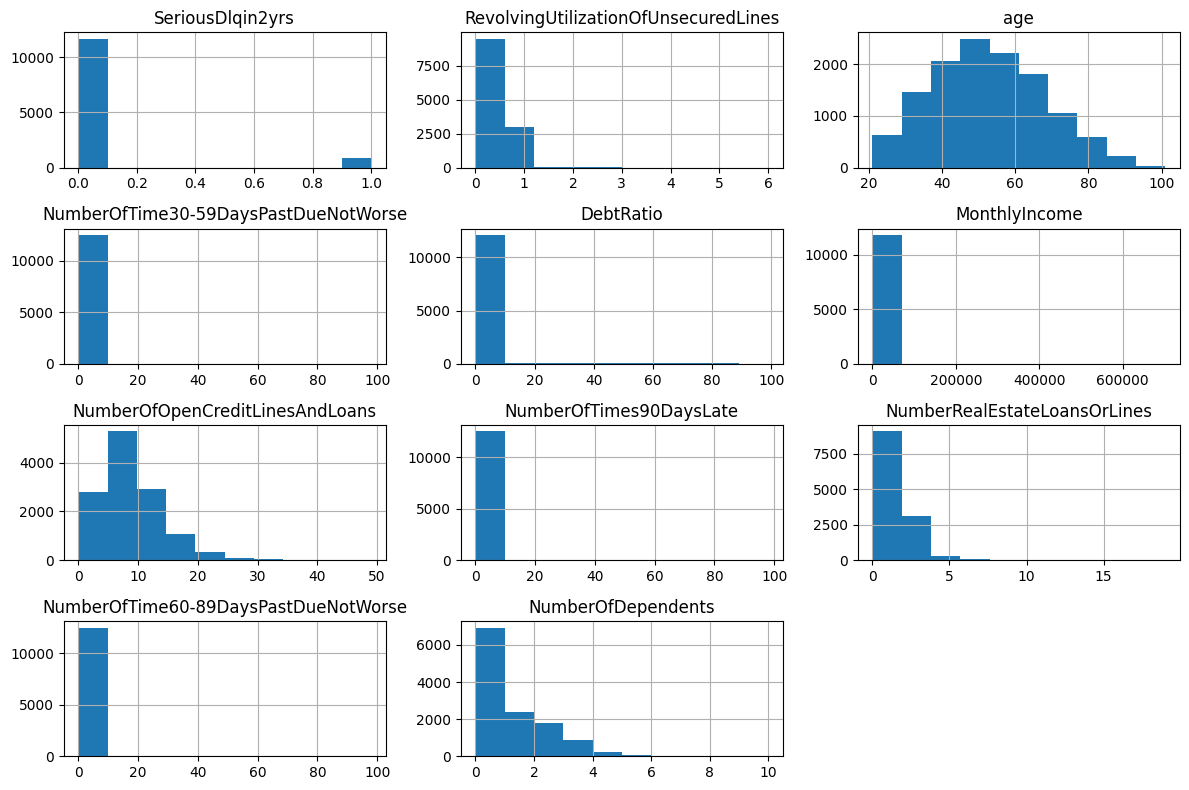

In [20]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [21]:
correlaciones = df.corr()[target].sort_values(ascending=False)
print(correlaciones)

SeriousDlqin2yrs                        1.000000
RevolvingUtilizationOfUnsecuredLines    0.281900
NumberOfTimes90DaysLate                 0.116649
NumberOfTime30-59DaysPastDueNotWorse    0.115229
NumberOfTime60-89DaysPastDueNotWorse    0.094080
NumberOfDependents                      0.045063
NumberRealEstateLoansOrLines            0.005743
DebtRatio                              -0.017445
MonthlyIncome                          -0.022199
NumberOfOpenCreditLinesAndLoans        -0.029063
age                                    -0.116908
Name: SeriousDlqin2yrs, dtype: float64


Los histogramas nos muestran la distribución de cada variable:

- **SeriousDlqin2yrs**: confirma el desbalance, casi todos los valores son 0
- **Age**: distribución normal, la mayoría entre 40 y 60 años
- **MonthlyIncome**: tiene outliers muy extremos (valores hasta 600.000), usaremos la mediana para imputar los nulos.
- **NumberOfDependents**: la mayoría tiene 0-2 dependientes
- **Las variables NumberOfTime**: muy concentradas en 0. La mayoría de personas no tiene retrasos en pagos
- **DebtRatio**: también muy concentrada con outliers extremos

En general casi todas las variables tienen outliers importantes y están muy concentradas en valores bajos.

- # Split Train/Test
    - Dividimos los datos en train (80%) y test (20%) antes de hacer nada más.
    - Usamos stratify para mantener la misma proporción de clases en ambos conjuntos.

In [13]:
train_set, test_set = train_test_split(df,test_size=0.2,random_state=42,stratify=df["SeriousDlqin2yrs"])
print("Tamaño train:", train_set.shape)
print("Tamaño test:", test_set.shape)

Tamaño train: (10029, 11)
Tamaño test: (2508, 11)


- # Imputaciones


In [14]:
# Asigno nombres 
num_depend = "NumberOfDependents"
mon_inc = "MonthlyIncome"

# NumberOfDependents: numerica discreta - usamos la MODA 
moda_train = train_set[num_depend].mode()[0]
train_set[num_depend] = train_set[num_depend].fillna(moda_train)
test_set[num_depend] = test_set[num_depend].fillna(moda_train)

In [ ]:
# MonthlyIncome: usamos la MEDIANA
mediana_train = train_set[mon_inc].median()
train_set[mon_inc] = train_set[mon_inc].fillna(mediana_train)
test_set[mon_inc] = test_set[mon_inc].fillna(mediana_train)

print("Nulos en train:", train_set.isnull().sum().sum())
print("Nulos en test:", test_set.isnull().sum().sum())

Nulos en train: 0
Nulos en test: 0


- # Genero X e Y 

In [22]:
#Tengo que separar las variables de entrada con las variables tarjet (las predicciones)
target = "SeriousDlqin2yrs"

# Features : Dame todas las columnas del dataframe excepto la que sea igual al target
features = [col for col in train_set.columns if col != target]

#Genero X e Y para train y test:
x_train = train_set [features]
y_train = train_set [target]

x_test = test_set [features]
y_test = test_set [target]

print("X_train:", x_train.shape)
print("X_test:", x_test.shape)


X_train: (10029, 10)
X_test: (2508, 10)


- # Escalado

In [27]:
escalado = StandardScaler()

x_train_esc = escalado.fit_transform(x_train)
x_test_esc = escalado.transform(x_test)

print("Escalado completado")

Escalado completado


- # Modelado

- Baseline con KNN : 
    - Entreno un KNN básico con K=7 como punto de partida.
    - Uso los datos escalados porque KNN mide distancias.

In [28]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train_esc, y_train)

print(classification_report(y_train, knn.predict(x_train_esc)))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      9338
           1       0.80      0.14      0.23       691

    accuracy                           0.94     10029
   macro avg       0.87      0.57      0.60     10029
weighted avg       0.93      0.94      0.92     10029



- El modelo baseline con KNN tiene un recall medio de 0.57.
- La clase 0 se predice muy bien (recall 1.00)
- Pero la clase 1 se predice muy mal (recall 0.14) debido al desbalance del dataset.
- Para mejorarlo voy a comparar varios modelos con validación cruzada

- # Comparativa modelos validación cruzada

In [29]:
modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Logistic": LogisticRegression(max_iter=10000),
    "RandomForest": RandomForestClassifier(max_depth=5, random_state=42),
    "LightGBM": LGBMClassifier(max_depth=5, random_state=42, verbose=-1)
}

for nombre, modelo in modelos.items():
    if nombre in ["KNN", "Logistic"]:
        score = np.mean(cross_val_score(modelo, x_train_esc, y_train, cv=5, scoring="balanced_accuracy"))
    else:
        score = np.mean(cross_val_score(modelo, x_train, y_train, cv=5, scoring="balanced_accuracy"))
    print(f"{nombre}: {score:.3f}")

KNN: 0.532
Logistic: 0.525
RandomForest: 0.553
LightGBM: 0.594


- Sin balanceo todos los modelos tienen un recall medio bajo (entre 0.52 y 0.59) porque el dataset está muy desbalanceado. 
- LightGBM es el mejor con 0.594.
- El siguiente paso es aplicar técnicas de balanceo para mejorar estos resultados.

- # Oversampling - Balanceo con SMOTE

- El dataset está muy desbalanceado (93.1% clase 0, 6.9% clase 1).
    1. Oversampling con SMOTE: crea ejemplos sintéticos de la clase minoritaria
    2. Undersampling: reduce ejemplos de la clase mayoritaria
    3. Hiperparámetros: ajustamos class_weight en los modelos

In [30]:
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)
x_train_smote_esc, y_train_smote_esc = smote.fit_resample(x_train_esc, y_train)

print("Tamaño original:", len(y_train))
print("Tamaño con SMOTE:", len(y_train_smote))
print("Distribución con SMOTE:\n", y_train_smote.value_counts())

Tamaño original: 10029
Tamaño con SMOTE: 18676
Distribución con SMOTE:
 SeriousDlqin2yrs
0    9338
1    9338
Name: count, dtype: int64


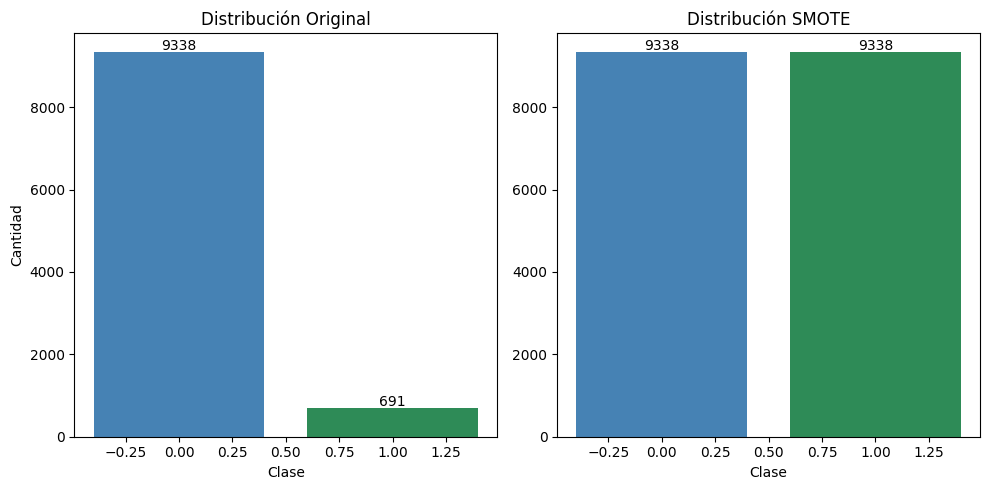

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Gráfica original
original = y_train.value_counts()
ax[0].bar(original.index, original.values, color=["steelblue", "seagreen"])
ax[0].set_title("Distribución Original")
ax[0].set_xlabel("Clase")
ax[0].set_ylabel("Cantidad")
for i, v in enumerate(original.values):
    ax[0].text(original.index[i], v + 50, str(v), ha="center")

# Gráfica SMOTE
smote_dist = y_train_smote.value_counts()
ax[1].bar(smote_dist.index, smote_dist.values, color=["steelblue", "seagreen"])
ax[1].set_title("Distribución SMOTE")
ax[1].set_xlabel("Clase")
for i, v in enumerate(smote_dist.values):
    ax[1].text(smote_dist.index[i], v + 50, str(v), ha="center")

plt.tight_layout()
plt.show()

In [32]:
modelos_smote = {
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Logistic": LogisticRegression(max_iter=10000),
    "RandomForest": RandomForestClassifier(max_depth=5, random_state=42),
    "LightGBM": LGBMClassifier(max_depth=5, random_state=42, verbose=-1)
}

for nombre, modelo in modelos_smote.items():
    if nombre in ["KNN", "Logistic"]:
        score = np.mean(cross_val_score(modelo, x_train_smote_esc, y_train_smote_esc, cv=5, scoring="balanced_accuracy"))
    else:
        score = np.mean(cross_val_score(modelo, x_train_smote, y_train_smote, cv=5, scoring="balanced_accuracy"))
    print(f"{nombre}: {score:.3f}")

KNN: 0.898
Logistic: 0.758
RandomForest: 0.817
LightGBM: 0.901


| Modelo | Sin balanceo | Con SMOTE | Mejora |
|--------|-------------|-----------|--------|
| KNN | 0.532 | 0.898 | +0.366 |
| Logistic | 0.525 | 0.758 | +0.233 |
| RandomForest | 0.553 | 0.817 | +0.264 |
| LightGBM | 0.594 | 0.901 | +0.307 |

Con SMOTE todos los modelos mejoran. LightGBM sigue siendo el mejor con 0.901 de recall medio, seguido por KNN con 0.898.
El balanceo de datos ha sido clave para mejorar los resultados.

- # Undersampling

- Undersampling reduce la clase mayoritaria (clase 0) hasta igualarla con la minoritaria (clase 1).
- Ventaja: más rápido. Desventaja: se pierden datos reales.

In [35]:
# Separamos las clases
clase_0 = x_train[y_train == 0]
clase_1 = x_train[y_train == 1]

clase_0_esc = x_train_esc[y_train == 0]
clase_1_esc = x_train_esc[y_train == 1]

# Reducimos la clase mayoritaria al tamaño de la minoritaria
clase_0_under = resample(clase_0, replace=False, n_samples=len(clase_1), random_state=42)
clase_0_under_esc = resample(clase_0_esc, replace=False, n_samples=len(clase_1_esc), random_state=42)

# Combinamos
x_train_under = np.concatenate([clase_0_under, clase_1])
y_train_under = np.concatenate([y_train[y_train == 0][:len(clase_1)], y_train[y_train == 1]])

x_train_under_esc = np.concatenate([clase_0_under_esc, clase_1_esc])
y_train_under_esc = y_train_under.copy()

print("Tamaño con Undersampling:", len(y_train_under))
print("Clase 0:", sum(y_train_under == 0))
print("Clase 1:", sum(y_train_under == 1))

Tamaño con Undersampling: 1382
Clase 0: 691
Clase 1: 691


Ahora están equilibradas las dos clases. pero ahora tenemos solo 1.382 filas en vez de las 10.029 originales. Se han perdido muchísimos datos. Esa es la desventaja del undersampling

In [36]:
for nombre, modelo in modelos_smote.items():
    if nombre in ["KNN", "Logistic"]:
        score = np.mean(cross_val_score(modelo, x_train_under_esc, y_train_under_esc, cv=5, scoring="balanced_accuracy"))
    else:
        score = np.mean(cross_val_score(modelo, x_train_under, y_train_under, cv=5, scoring="balanced_accuracy"))
    print(f"{nombre}: {score:.3f}")

KNN: 0.729
Logistic: 0.750
RandomForest: 0.766
LightGBM: 0.748


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

| Modelo | Sin balanceo | SMOTE | Undersampling |
|--------|-------------|-------|---------------|
| KNN | 0.532 | 0.898 | 0.729 |
| Logistic | 0.525 | 0.758 | 0.750 |
| RandomForest | 0.553 | 0.817 | 0.766 |
| LightGBM | 0.594 | 0.901 | 0.748 |

SMOTE gana en casi todos los modelos.
El Undersampling mejora respecto a sin balanceo, pero peor que SMOTE porque se pierde muchos datos reales al reducir la clase mayoritaria de 9.338 a solo 691 casos.

- # Balanceo con hiperparámetros 

- En vez de modificar los datos, le decimos directamente a cada modelo que penalice más los errores en la clase minoritaria (clase 1).
- Esto se hace con el hiperparámetro class_weight="balanced".

In [37]:
modelos_cw = {
    "KNN": KNeighborsClassifier(n_neighbors=7, weights="distance"),
    "Logistic": LogisticRegression(max_iter=10000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    "LightGBM": LGBMClassifier(max_depth=5, random_state=42, class_weight="balanced", verbose=-1)
}

for nombre, modelo in modelos_cw.items():
    if nombre in ["KNN", "Logistic"]:
        score = np.mean(cross_val_score(modelo, x_train_esc, y_train, cv=5, scoring="balanced_accuracy"))
    else:
        score = np.mean(cross_val_score(modelo, x_train, y_train, cv=5, scoring="balanced_accuracy"))
    print(f"{nombre}: {score:.3f}")

KNN: 0.535
Logistic: 0.756
RandomForest: 0.764
LightGBM: 0.744


| Modelo | Sin balanceo | SMOTE | Undersampling | Class Weight |
|--------|-------------|-------|---------------|--------------|
| KNN | 0.532 | 0.898 | 0.729 | 0.535 |
| Logistic | 0.525 | 0.758 | 0.750 | 0.756 |
| RandomForest | 0.553 | 0.817 | 0.766 | 0.764 |
| LightGBM | 0.594 | 0.901 | 0.748 | 0.744 |

Conclusión: SMOTE es la mejor técnica de balanceo en casi todos los modelos.
LightGBM con SMOTE es el modelo ganador con un recall medio de 0.901.
Se procederá a optimizar sus hiperparámetros con GridSearchCV.

- # Optimizaxión de hiperparámetros 

- Voy a usar GridSearchCV para encontrar la mejor combinación de hiperparámetros para LightGBM entrenado con SMOTE.
- GridSearchCV prueba todas las combinaciones posibles y se queda con la mejor.

In [38]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.1, 0.5],
    "max_depth": [5, 10],
    "class_weight": ["balanced", None]
}

lgb = LGBMClassifier(random_state=42, verbose=-1)

lgb_grid = GridSearchCV(lgb,
                        param_grid=param_grid,
                        cv=5,
                        scoring="balanced_accuracy",
                        n_jobs=-1)

lgb_grid.fit(x_train_smote, y_train_smote)

print("Mejores hiperparámetros:", lgb_grid.best_params_)
print("Mejor score:", lgb_grid.best_score_)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

Mejores hiperparámetros: {'class_weight': 'balanced', 'learning_rate': 0.5, 'max_depth': 10, 'n_estimators': 200}
Mejor score: 0.9368210861703726


GridSearchCV encontró la mejor combinación de hiperparámetros con un recall medio de 0.937, mejorando el 0.901 que teníamos antes.
Los mejores hiperparámetros son:
- class_weight: balanced
- learning_rate: 0.5
- max_depth: 10
- n_estimators: 200

- # Evaluación final contra test

In [39]:
print(classification_report(y_test, lgb_grid.best_estimator_.predict(x_test)))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      2335
           1       0.31      0.37      0.34       173

    accuracy                           0.90      2508
   macro avg       0.63      0.65      0.64      2508
weighted avg       0.91      0.90      0.90      2508



El modelo final obtiene un recall medio de 0.65 contra datos nuevos.
- Clase 0 (sin problemas): recall 0.94 → detecta bien los casos negativos
- Clase 1 (con problemas): recall 0.37 → detecta el 37% de los casos positivos

El modelo es conservador detectando problemas financieros, lo que en un caso real podría suponer perder clientes de riesgo.

- # Análisis de Errores

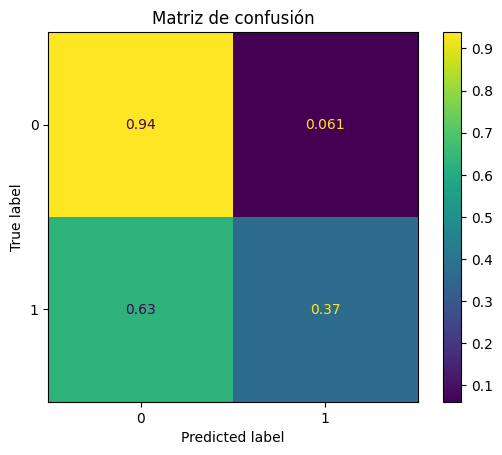

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test,lgb_grid.best_estimator_.predict(x_test),normalize="true")
plt.title("Matriz de confusión")
plt.show()

La matriz de confusión muestra que:
- El modelo detecta muy bien la clase 0 (94% de acierto)
- El modelo falla bastante en la clase 1, solo detecta el 37% de las personas con problemas financieros
- El 63% de las personas con problemas reales son clasificadas como "sin problemas" (falsos negativos)

En un caso real esto sería peligroso porque el banco estaría dando crédito a personas con alto riesgo de impago.
Para mejorar se podría ajustar el threshold de decisión por debajo de 0.5 para detectar más casos de la clase 1.